Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
                  file  shannon_entropy  gini_coefficient  morans_i_1d
0               wt.csv         3.007730         20.989120     0.947671
1          hypoxia.csv         3.485555          7.390472     0.927735
2           latent.csv         8.974048        -26.702423     0.760497
3          napm-ko.csv         3.676685        -28.117352     0.942586
4  napm-ko-hypoxia.csv         5.083292       6183.791343     0.863184


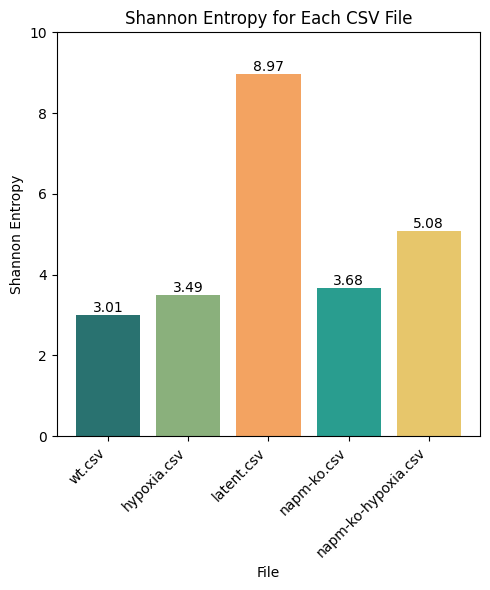

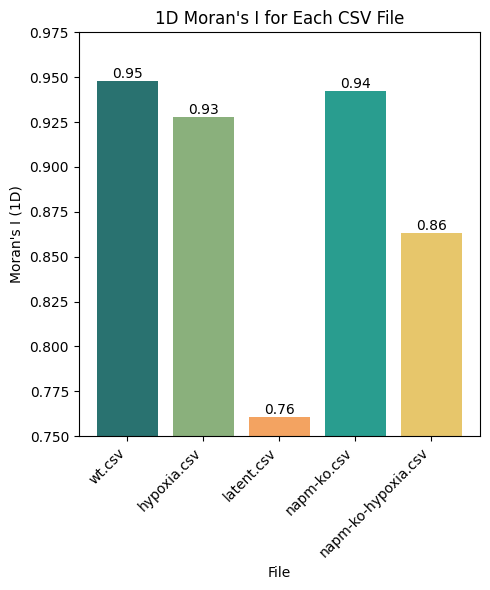

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# 按照指定顺序和对应颜色
files_order = ['wt.csv', 'hypoxia.csv', 'latent.csv','napm-ko.csv',  'napm-ko-hypoxia.csv']
colors = ['#297270', '#8ab07c', '#f3a361',  '#299d8f','#e7c66b']

# 定义 Shannon 熵函数
def shannon_entropy(data):
    unique_vals, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

# 定义 Gini 系数函数
def gini_coefficient(data):
    n = len(data)
    mu = np.mean(data)
    diff_matrix = np.abs(np.subtract.outer(data, data))
    sum_diff = np.sum(diff_matrix)
    return sum_diff / (2 * n**2 * mu)

# 定义 1D Moran's I 指数函数
def morans_i_1d(data):
    n = len(data)
    mean_data = np.mean(data)
    w = np.zeros((n, n))
    for i in range(n):
        if i > 0:
            w[i, i-1] = 1
        if i < n - 1:
            w[i, i+1] = 1

    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += w[i, j] * (data[i] - mean_data) * (data[j] - mean_data)
    denominator = np.sum((data - mean_data) ** 2)
    
    return (n * numerator) / (denominator * np.sum(w))

# CSV 文件所在目录
data_dir = './DI-score/'

results = []
for file_name in files_order:
    file_path = os.path.join(data_dir, file_name)
    try:
        df = pd.read_csv(file_path, header=None)
        # 判断数据为行向量或列向量
        if df.shape[0] == 1:
            data = df.values.flatten()
        elif df.shape[1] == 1:
            data = df.values.flatten()
        else:
            data = df.iloc[0, :].values
        
        # 截断数据：大于 2 的值变为 2，小于 -2 的值变为 -2
        data = np.clip(data, -2, 2)
        
        se = shannon_entropy(data)
        gini = gini_coefficient(data)
        moran = morans_i_1d(data)
        
        results.append({
            'file': file_name,
            'shannon_entropy': se,
            'gini_coefficient': gini,
            'morans_i_1d': moran
        })
    except Exception as e:
        print(f"处理文件 {file_name} 时出错：{e}")

results_df = pd.DataFrame(results)
print(results_df)

# 绘制 Shannon 熵柱状图，使用指定颜色并添加数值标注
plt.figure(figsize=(5, 6))
bars = plt.bar(results_df['file'], results_df['shannon_entropy'], color=colors)
plt.xlabel('File')
plt.ylabel('Shannon Entropy')
plt.title('Shannon Entropy for Each CSV File')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 10)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('DI-score/shannon_entropy.pdf')
plt.show()

# 绘制 1D Moran's I 指数柱状图，使用指定颜色并添加数值标注
plt.figure(figsize=(5, 6))
bars = plt.bar(results_df['file'], results_df["morans_i_1d"], color=colors)
plt.xlabel('File')
plt.ylabel("Moran's I (1D)")
plt.title("1D Moran's I for Each CSV File")
plt.xticks(rotation=45, ha='right')
plt.ylim(0.75,0.975)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('DI-score/moran.pdf')
plt.show()


                  file  shannon_entropy  gini_coefficient  morans_i_1d
0               wt.csv         3.007730         20.989120     0.947671
1          hypoxia.csv         3.485555          7.390472     0.927735
2           latent.csv         8.974048        -26.702423     0.760497
3          napm-ko.csv         3.676685        -28.117352     0.942586
4  napm-ko-hypoxia.csv         5.083292       6183.791343     0.863184


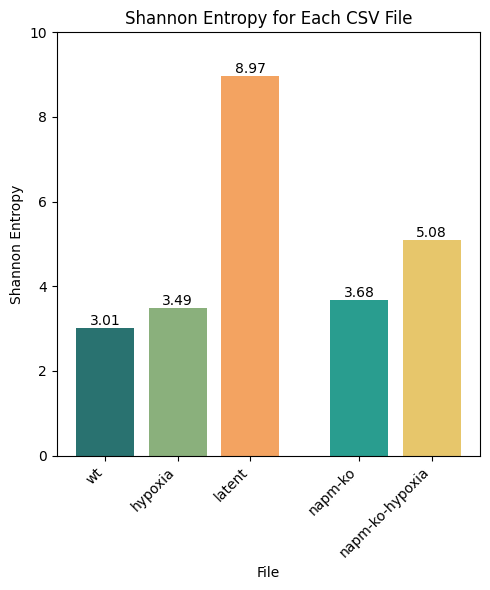

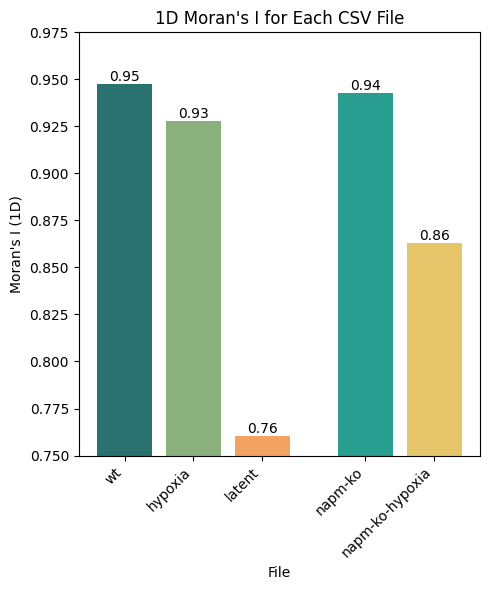

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

# 按照指定顺序和对应颜色
files_order = ['wt.csv', 'hypoxia.csv', 'latent.csv', 'napm-ko.csv', 'napm-ko-hypoxia.csv']
colors = ['#297270', '#8ab07c', '#f3a361', '#299d8f', '#e7c66b']

# 定义 Shannon 熵函数
def shannon_entropy(data):
    unique_vals, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

# 定义 Gini 系数函数
def gini_coefficient(data):
    n = len(data)
    mu = np.mean(data)
    diff_matrix = np.abs(np.subtract.outer(data, data))
    sum_diff = np.sum(diff_matrix)
    return sum_diff / (2 * n**2 * mu)

# 定义 1D Moran's I 指数函数
def morans_i_1d(data):
    n = len(data)
    mean_data = np.mean(data)
    w = np.zeros((n, n))
    for i in range(n):
        if i > 0:
            w[i, i-1] = 1
        if i < n - 1:
            w[i, i+1] = 1

    numerator = 0
    for i in range(n):
        for j in range(n):
            numerator += w[i, j] * (data[i] - mean_data) * (data[j] - mean_data)
    denominator = np.sum((data - mean_data) ** 2)
    
    return (n * numerator) / (denominator * np.sum(w))

# CSV 文件所在目录
data_dir = './DI-score/'

results = []
for file_name in files_order:
    file_path = os.path.join(data_dir, file_name)
    try:
        df = pd.read_csv(file_path, header=None)
        if df.shape[0] == 1:
            data = df.values.flatten()
        elif df.shape[1] == 1:
            data = df.values.flatten()
        else:
            data = df.iloc[0, :].values
        
        data = np.clip(data, -2, 2)
        
        se = shannon_entropy(data)
        gini = gini_coefficient(data)
        moran = morans_i_1d(data)
        
        results.append({
            'file': file_name,
            'shannon_entropy': se,
            'gini_coefficient': gini,
            'morans_i_1d': moran
        })
    except Exception as e:
        print(f"处理文件 {file_name} 时出错：{e}")

results_df = pd.DataFrame(results)
print(results_df)

# 自定义 x 轴位置，在 latent 和 napm-ko 之间加大间距
x_positions = [0, 1, 2, 3.5, 4.5]

# 更美观的标签
x_labels = ['wt', 'hypoxia', 'latent', 'napm-ko', 'napm-ko-hypoxia']

# 绘制 Shannon 熵柱状图
plt.figure(figsize=(5, 6))
bars = plt.bar(x_positions, results_df['shannon_entropy'], color=colors, width=0.8)
plt.xlabel('File')
plt.ylabel('Shannon Entropy')
plt.title('Shannon Entropy for Each CSV File')
plt.xticks(x_positions, x_labels, rotation=45, ha='right')
plt.ylim(0, 10)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('DI-score/shannon_entropy.pdf')
plt.show()

# 绘制 Moran's I 柱状图
plt.figure(figsize=(5, 6))
bars = plt.bar(x_positions, results_df['morans_i_1d'], color=colors, width=0.8)
plt.xlabel('File')
plt.ylabel("Moran's I (1D)")
plt.title("1D Moran's I for Each CSV File")
plt.xticks(x_positions, x_labels, rotation=45, ha='right')
plt.ylim(0.75, 0.975)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('DI-score/moran.pdf')
plt.show()